# Data types and IO

#### Import general modules

mpi4py is always required when using these tools. Numpy is always good to have if any manipulation is to be done.

In [99]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

#### Import modules from pysemtools

In this case we will import all the data types that we currently support, as well as io functions that are required to populate them.

In [100]:
# Data types
from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.coef import Coef
from pysemtools.datatypes.field import Field, FieldRegistry

# Readers
from pysemtools.io.ppymech.neksuite import preadnek, pynekread

# Writers
from pysemtools.io.ppymech.neksuite import pwritenek, pynekwrite

fname_2d = '../data/mixlay0.f00001'
fname_3d = '../data/rbc0.f00001'

## Mesh

The mesh object is designed to interact with the coordinates of the SEM domain. It goes without saying then, that if a file is used to initialize the object, it must contain the mesh.

### Initializing

The mesh object can be initialized in multiple manners that we have ideantified to be typical when post processing data, here we show some of them.

#### Initializing an empty object

We can initialize an empty mesh object by just providing the communicator.

Note that at this stage we must indicate if we want to find the connectivity of the points. This is important if later one whishes to average points at element interfaces. Be carefull, however, as it will require more memory.

In [101]:
msh_2d = Mesh(comm)
msh_3d = Mesh(comm)

#### Initializing from a file

The standard way to initialize the data in a mesh object requires that an empty object is initialized and the the pynekread function is called. This function will take the empty object and read only the data containing the mesh.

One must give the name and the empty object that will hold the data. Aditionally, the type of the data is an input.

In [102]:
pynekread(fname_2d, comm, data_dtype=np.double, msh=msh_2d)
pynekread(fname_3d, comm, data_dtype=np.single, msh=msh_3d)

2026-03-04 15:58:14,031  pynekread             INFO      Reading file: ../data/mixlay0.f00001
2026-03-04 15:58:14,040  Mesh                  INFO      Mesh object initialized from coordinates with type: float64 - Elapsed time: 0.005635906000065916s
2026-03-04 15:58:14,041  pynekread             INFO      File successfully read - Elapsed time: 0.010121335000008003s
2026-03-04 15:58:14,041  pynekread             INFO      Reading file: ../data/rbc0.f00001
2026-03-04 15:58:14,061  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.015129852999962168s
2026-03-04 15:58:14,062  pynekread             INFO      File successfully read - Elapsed time: 0.020931777999976475s


#### Initializing from a hexadata object.

We have previously use the module pymech to post process data. Because of this we wrote io routines that produce objects of this type, in case some existing workflows already rely on that. We note that this is parallel and each rank will have a hexadata object with a portion of the total data.

Note that in our implementation, the hexadata object will always read the full file.

In general, this should not be the main way to initialize objects. But we give the option.

The steps that we follow to initialize are the following:

1. Read the hexadata object.
2. Initialize the mesh object from it

In [103]:
# 1.
data_2d = preadnek(fname_2d, comm, data_dtype=np.double)
data_3d = preadnek(fname_3d, comm, data_dtype=np.single)
# 2. 
msh_2d = Mesh(comm, data=data_2d)
msh_3d = Mesh(comm, data=data_3d)

2026-03-04 15:58:14,072  preadnek              INFO      Reading file: ../data/mixlay0.f00001
2026-03-04 15:58:14,253  preadnek              INFO      Elapsed time: 0.18158228199990845s
2026-03-04 15:58:14,261  preadnek              INFO      Reading file: ../data/rbc0.f00001
2026-03-04 15:58:14,291  preadnek              INFO      Elapsed time: 0.02974485899994761s
2026-03-04 15:58:14,294  Mesh                  INFO      Initializing Mesh object from HexaData object.
2026-03-04 15:58:14,306  Mesh                  INFO      Mesh object initialized.
2026-03-04 15:58:14,306  Mesh                  INFO      Mesh data is of type: float64
2026-03-04 15:58:14,307  Mesh                  INFO      Elapsed time: 0.013255767000032392s
2026-03-04 15:58:14,308  Mesh                  INFO      Initializing Mesh object from HexaData object.
2026-03-04 15:58:14,323  Mesh                  INFO      Mesh object initialized.
2026-03-04 15:58:14,323  Mesh                  INFO      Mesh data is of type: 

#### Initializing from an ndarray

In some instances, one might create the SEM coordinates directly in python. If that is the case, starting directly from the coordinates as an array is also a possibility. One would first create an empty object and the initialize from coordinates as follow:

In [104]:
# 1.Copy the coordinates from before just to show

x = msh_3d.x.copy().astype(np.float64)
y = msh_3d.y.copy().astype(np.float64)
z = msh_3d.z.copy().astype(np.float64)

# 2.Initialize a new mesh object
msh_3d_sub = Mesh(comm)
msh_3d_sub.init_from_coords(comm, x=x, y=y, z=z)

2026-03-04 15:58:14,351  Mesh                  INFO      Mesh object initialized from coordinates with type: float64 - Elapsed time: 0.017054289000043354s


In this case, just to show a simple manipulation, we casted the arrays from single to double precision

## Coef

The coef object holds the jacobian matrix components, mass matrix and routines to perform derivatives and integrals in the SEM mesh. It is always initialized from a mesh object.

One aditional option for 3D meshes is to also obtain integration weights for the area of the facets in the SEM mesh. If you do not need it, do not activate it, as this takes some extra time and requires extra memory.

The data type of the coef object attributes will match the type of the mesh object.

In [105]:
coef_2d = Coef(msh_2d, comm)
coef_3d = Coef(msh_3d, comm)

2026-03-04 15:58:14,360  Coef                  INFO      Initializing Coef object
2026-03-04 15:58:14,361  Coef                  INFO      Getting derivative matrices
2026-03-04 15:58:14,364  Coef                  INFO      Calculating the components of the jacobian
2026-03-04 15:58:14,369  Coef                  INFO      Calculating the jacobian determinant and inverse of the jacobian matrix
2026-03-04 15:58:14,371  Coef                  INFO      Calculating the mass matrix
2026-03-04 15:58:14,372  Coef                  INFO      Coef object initialized
2026-03-04 15:58:14,373  Coef                  INFO      Coef data is of type: float64
2026-03-04 15:58:14,373  Coef                  INFO      Elapsed time: 0.013466366999978163s
2026-03-04 15:58:14,374  Coef                  INFO      Initializing Coef object
2026-03-04 15:58:14,374  Coef                  INFO      Getting derivative matrices
2026-03-04 15:58:14,378  Coef                  INFO      Calculating the components of the 

## Field

The field object is designed to hold the data from SEM fields in a way that intefacing to a nek5000 binary file is easily achieved.

The initialization can be done in similar ways as the mesh, i.e., by using hexadata and the pynekread routine.

### Initializing

#### Initializing an empty object.

We follow the same procedure to initialize an empty object.

In [106]:
fld_2d = Field(comm)
fld_3d = Field(comm)

#### Initializing from a file

Using the pynekread routine, one can follow the same procedure. In this case, if only the fld file is indicated as input, the mesh in the file will not be read

In [107]:
pynekread(fname_2d, comm, data_dtype=np.double, fld=fld_2d)
pynekread(fname_3d, comm, data_dtype=np.single, fld=fld_3d)

2026-03-04 15:58:14,419  pynekread             INFO      Reading file: ../data/mixlay0.f00001
2026-03-04 15:58:14,423  pynekread             INFO      File successfully read - Elapsed time: 0.0040701989998979116s
2026-03-04 15:58:14,424  pynekread             INFO      Reading file: ../data/rbc0.f00001
2026-03-04 15:58:14,429  pynekread             INFO      File successfully read - Elapsed time: 0.00529200400001173s


Note that you can read both mesh and fields with pynekread if you specify both keywords, i.e, msh= and fld=


#### Initializing from hexadata

Just as for the mesh, the same interface is valid.

In [108]:
# 1.
data_2d = preadnek(fname_2d, comm, data_dtype=np.double)
data_3d = preadnek(fname_3d, comm, data_dtype=np.single)
# 2. 
fld_2d = Field(comm, data=data_2d)
fld_3d = Field(comm, data=data_3d)

2026-03-04 15:58:14,444  preadnek              INFO      Reading file: ../data/mixlay0.f00001
2026-03-04 15:58:14,533  preadnek              INFO      Elapsed time: 0.08818987199992989s
2026-03-04 15:58:14,537  preadnek              INFO      Reading file: ../data/rbc0.f00001
2026-03-04 15:58:14,573  preadnek              INFO      Elapsed time: 0.036531340999999884s
2026-03-04 15:58:14,588  Field                 INFO      Field object initialized from HexaData - Elapsed time: 0.013049441000021034s
2026-03-04 15:58:14,595  Field                 INFO      Field object initialized from HexaData - Elapsed time: 0.005147600999976021s



### Contents of the field object

The field object contains all the information in a subdirectory called fields that is divided into the conventions of a nek5000 binary format.

The keywords are:

In [109]:
for key in fld_2d.fields.keys():
    print(f'{key} has {len(fld_2d.fields[key])} fields')

print('=================')

for key in fld_3d.fields.keys():
    print(f'{key} has {len(fld_3d.fields[key])} fields')

vel has 2 fields
pres has 1 fields
temp has 1 fields
scal has 2 fields
vel has 3 fields
pres has 1 fields
temp has 1 fields
scal has 0 fields


Each keword has a list of fields depending on the contents of the file. Note how the 2 files that we test here have different information.

To access the content of the files, one can do something like this:

In [110]:
u = fld_3d.fields['vel'][0]
v = fld_3d.fields['vel'][1]
w = fld_3d.fields['vel'][2]
p = fld_3d.fields['pres'][0]
t = fld_3d.fields['temp'][0]

### Adding new ndarrays to the field

If one wishes to add new data, it is as simple as appending arrays to any of the keys of the field object. Given that nek5000 readers follow certain logic, it is always safer to add new data to the scalars, unless one wishes to overwrite velocity, pressure, and/or temperature.

For example, we can add the velocity magnitude as a scalar with:

In [111]:
mag = np.sqrt(u**2 + v**2 + w**2)
fld_3d.fields['scal'].append(mag)
fld_3d.update_vars()

If one adds new data, it is needed that one calls the update_vars method to update the attributes that keep track of the number of fields in the field object. This is needed, for example, if one wishes to write data to disk.

## Writing out data

Writing the data out always needs a mesh and field object, even if one does not wish to write the mesh out.

The procedure is as simple as follows:

In [112]:
fname_out = '../data/out_rbc0.f00001'

pynekwrite(fname_out, comm, msh=msh_3d, fld=fld_3d, write_mesh=True, wdsz=4)

2026-03-04 15:58:14,644  pynekwrite            INFO      Writing file: ../data/out_rbc0.f00001
2026-03-04 15:58:14,656  pynekwrite            INFO      File written - Elapsed time: 0.012334320000036314s


## Field registry

The field registry is a class that extends the field class. We believe this is the class that should be used instead of fields, as it allows to do the same things, but with some extra flexibility.

The methods to initialize it and write data with it are the same. It also contains the fields attribute with a list of the present fields. 

It however, has an additional registry attribute that names and points to each field.

In [113]:
fld_3d_r = FieldRegistry(comm)
pynekread(fname_3d, comm, data_dtype=np.single, fld=fld_3d_r)

2026-03-04 15:58:14,669  pynekread             INFO      Reading file: ../data/rbc0.f00001
2026-03-04 15:58:14,675  Field                 INFO      Field registry updated with: ['u', 'v', 'w', 'p', 't'] - dtype: float32
2026-03-04 15:58:14,677  pynekread             INFO      File successfully read - Elapsed time: 0.007462326999984725s


In [114]:
for key in fld_3d_r.registry.keys():
    print(f'{key} has {fld_3d_r.registry[key].dtype} dtype')

u has float32 dtype
v has float32 dtype
w has float32 dtype
p has float32 dtype
t has float32 dtype


Note that all the fields that have been adressed as indices in a list have now been assigned names.

### Adding new fields

#### From memory

Adding new fields can now also been done very easy as well. Here we can add a new field named mag that is the velocity magnitude calculated earlier.

This field will be added as an scalar to the fields attribute.

In [115]:
fld_3d_r.add_field(comm, field_name='mag', field=mag, dtype=mag.dtype)
print(f'Field mag added to registry and fields directory in pos {fld_3d_r.registry_pos["mag"]}')

Field mag added to registry and fields directory in pos scal_0


#### From disk

You can also just read one field from a file, which reduces the memory footprint.

The procesude is shown below, note that here we know that we have written the field mag as an scalar.

In [116]:
fld_3d_r.add_field(comm, field_name='mag_r', file_name=fname_out, file_type='fld', file_key='scal_0', dtype=mag.dtype)
print(f'Field mag_r added to registry and fields directory in pos {fld_3d_r.registry_pos["mag_r"]}')

2026-03-04 15:58:14,736  pynekread_field       INFO      Reading field: scal_0 from file: ../data/out_rbc0.f00001
2026-03-04 15:58:14,753  pynekread_field       INFO      File read
2026-03-04 15:58:14,755  pynekread_field       INFO      Elapsed time: 0.018543514999919353s
Field mag_r added to registry and fields directory in pos scal_1


Let's compare the field that we previously wrote with the one we calculated

In [117]:
eq = np.allclose(fld_3d_r.registry['mag'], fld_3d_r.registry['mag_r'])
print(eq)

True


### Some considerations when dealing with the registry

In our implementation, each member of the registry is linked to a member of the lists contained in the fields attribute.

For the link to be mantained, we must modify the registry in place, not reassing fields to it.

If you would like to replace an entry in the field registry, then use the add field method with the same key

Lets experiment adding a field full of ones. Based on the order of our operations, we know it is stored in scal 2. You can also check the registry_pos attribute:

In [118]:
fld_3d_r.add_field(comm, field_name='ones', field=np.ones_like(mag), dtype=mag.dtype)
print(fld_3d_r.registry_pos['ones'])
print(fld_3d_r.registry['ones'][100,0,:,:])
print(fld_3d_r.fields['scal'][2][100,0,:,:])

scal_2
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]


If I modify the registry, the list is modified:

In [119]:
fld_3d_r.registry['ones'][100,0,:,:] = 2.0
print(fld_3d_r.fields['scal'][2][100,0,:,:])

[[2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]]


The same happens in the opposite direction

In [120]:
fld_3d_r.fields['scal'][2][100,0,:,:] = 3.0
print(fld_3d_r.registry['ones'][100,0,:,:])

[[3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3. 3. 3.]]


However if you try to assing a field directly to the registry, you will get an error:



In [121]:
zeros = np.zeros_like(mag)

try:
    fld_3d_r.registry['ones'] = zeros
except KeyError as e:
    print(e)

"Key 'ones' already exists. Cannot overwrite existing array without the add field method"


But see that if you add the field again with the proper method, then it should work as you want

In [122]:
fld_3d_r.add_field(comm, field_name='ones', field=zeros, dtype=zeros.dtype)
print(fld_3d_r.fields['scal'][2][100,0,:,:])

2026-03-04 15:58:14,873  Field                 WARNING   Field ones already in registry. Overwriting
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


## HDF5

The nek-type files require the Mesh and Field/FieldRegistry classes to hold the data. This is due to the clear structure that those files have. 

PySEMTools also supports other type of files. In particular, HDF files. While in general, one can simply use hdf5 with h5py, PySEMTools provides objects that allow to manage parallel I/O in a much simpler manner. These files, however, do not require a structure and the data is managed by keys given by the user. As an example, here we write the data from the Mesh and Field into an hdf5 file

> Any numpy array can be written using this object. It does not need to come from the PySEMTools objects.

In [123]:
from pysemtools.io.hdf import HDF5File

# Set inputs
fname = '../data/out_rbc00001.hdf5'
mode = 'w' # Read mode "r" or write mode "w"
parallel = True # Whether to use parallel IO driver (you need mpi-aware HDF5) In this notebook, the executions gets set to serial since we run in one rank
distributed_axis = 0 # The axis along the data will be (or is) partitioned among ranks. For SEM data, axis 0 is the one that indexes the elements

# Open a file
hdf5_file = HDF5File(comm, fname, mode, parallel)

# Write the mesh into a "mesh" group (This is not required)
hdf5_file.write_dataset("/mesh/x", msh_3d.x, distributed_axis=0)
hdf5_file.write_dataset("/mesh/y", msh_3d.y, distributed_axis=0)
hdf5_file.write_dataset("/mesh/z", msh_3d.z, distributed_axis=0)

# Write the data in the field registry
for key in fld_3d_r.registry.keys():
    data = fld_3d_r.registry[key]
    hdf5_file.write_dataset(f"/fields/{key}", data, distributed_axis=0)

# Close the file
hdf5_file.close()

2026-03-04 15:58:14,906  HDF5File              INFO      ../data/out_rbc00001.hdf5 opened - mode w - serial
2026-03-04 15:58:14,939  HDF5File              INFO      ../data/out_rbc00001.hdf5 closed - Elapsed time: 0.03635136200000488s


Having this, it is then possible to read the data and check that all is correct. Please note that the subgroups in the HDF5 for this case are for ilustration.

In [124]:
hdf5_file = HDF5File(comm, fname, mode='r', parallel=True)
# Check the mesh
xh = hdf5_file.read_dataset("/mesh/x", dtype=np.double, distributed_axis=0)
print(f"X coordinates match: {np.allclose(xh, msh_3d.x)}")
xh = hdf5_file.read_dataset("/mesh/y", dtype=np.double, distributed_axis=0)
print(f"Y coordinates match: {np.allclose(xh, msh_3d.y)}")
xh = hdf5_file.read_dataset("/mesh/z", dtype=np.double, distributed_axis=0)
print(f"Z coordinates match: {np.allclose(xh, msh_3d.z)}")

# Check the fields
for key in fld_3d_r.registry.keys():
    datah = hdf5_file.read_dataset(f"/fields/{key}", dtype=fld_3d_r.registry[key].dtype, distributed_axis=0)
    print(f"Field {key} matches: {np.allclose(datah, fld_3d_r.registry[key])}")
hdf5_file.close()

2026-03-04 15:58:14,978  HDF5File              INFO      ../data/out_rbc00001.hdf5 opened - mode r - serial
X coordinates match: True
Y coordinates match: True
Z coordinates match: True
Field u matches: True
Field v matches: True
Field w matches: True
Field p matches: True
Field t matches: True
Field mag matches: True
Field mag_r matches: True
Field ones matches: True
2026-03-04 15:58:15,087  HDF5File              INFO      ../data/out_rbc00001.hdf5 closed - Elapsed time: 0.10908896199998708s


## VTKHDF

To visualize files from HDF5, one can use the VTKHDF format. Which is an HDF5 file with a more strict structure, where connectivity is created.

Our objects work for 3D and 4D arrays. 
- For 3D arrays, we assume that the mesh is written in a `meshgrid` style, so vtk cells are built from neighbouring points. 
- For 4D arrays, we assume that the data is coming from a `SEM` mesh, where the axis 0  represents the elements. So the connectivity is built with that in mind. 

> All of these objects work in parallel, however for VTKHDF, the distributed_axis **has** to be equal to `0`. This is simply due to how the data is dumped into files by the different ranks
> This requirement might be relaxed in the future.

Note that for this case, we **need** a mesh, which is written in a specific way so vtk readers can understand it. At the moment, we write all the fields as `PointData`. So the structure of these files is certainly more strict than simply `HDF5`

Similarly to the previous example, the data can be written as follows:

In [125]:
from pysemtools.io.hdf import VTKHDFFile

# Set inputs
fname = '../data/out_rbc00001.vtkhdf'

# Write VTKHDF data
fw = VTKHDFFile(comm, fname, "w", parallel=True)
fw.write_mesh_data(msh_3d.x, msh_3d.y, msh_3d.z)
for key in fld_3d_r.registry.keys():
    fw.write_point_data(key, fld_3d_r.registry[key])
fw.close()

2026-03-04 15:58:15,117  HDF5File              INFO      ../data/out_rbc00001.vtkhdf opened - mode w - serial


2026-03-04 15:58:15,750  HDF5File              INFO      ../data/out_rbc00001.vtkhdf closed - Elapsed time: 0.6464613679999047s


> Note that this is very useful if you want to visualize interpolation points in 3D (tutorials of interpolation are found in section 4 of the examples in PySEMTools)

This file can be read with paraview (among other software) to produce:

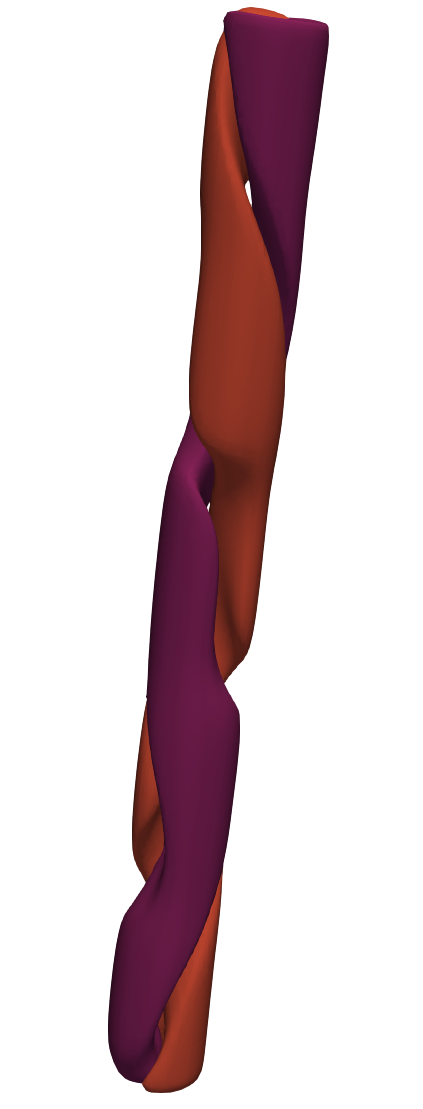

In [126]:
from IPython.display import Image, display
display(Image("../data/rbc_vtkhdf.png"))

## Wrappers

In the event that all you want is a numpy array with the data, you can also use a wrapper to retrieve the data.

The wrappers also work for hdf5 and vtkhdf files. In those cases, everything is selected based on the extension of the file name.

In [127]:
from pysemtools.io.wrappers import read_data

data = read_data(comm, fname_out, ["x", "y", "z", "scal_0"], dtype = np.single)

2026-03-04 15:58:15,780  pynekread             INFO      Reading file: ../data/out_rbc0.f00001
2026-03-04 15:58:15,802  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.01716634100000647s
2026-03-04 15:58:15,803  pynekread             INFO      File successfully read - Elapsed time: 0.023492424000096435s
2026-03-04 15:58:15,805  pynekread_field       INFO      Reading field: scal_0 from file: ../data/out_rbc0.f00001
2026-03-04 15:58:15,807  pynekread_field       INFO      File read
2026-03-04 15:58:15,808  pynekread_field       INFO      Elapsed time: 0.0037234540000099514s


data is a dictionary that contains the data of the keys that were given.

In [128]:
print(np.allclose(data["x"], msh_3d.x))
print(np.allclose(data["y"], msh_3d.y))
print(np.allclose(data["z"], msh_3d.z))
print(np.allclose(data["scal_0"], fld_3d_r.registry['mag_r']))

True
True
True
True


## Inspecting memory usage

To inspect the memory usage, one can use the monitoring module

In [129]:
from pysemtools.monitoring.memory_monitor import MemoryMonitor

mm = MemoryMonitor()

You can chose to inspect the total memory used, or check the ussage of each attibute.

In [130]:
mm.object_memory_usage(comm, msh_3d, "mesh_3d", print_msg=False)
mm.object_memory_usage_per_attribute(comm, msh_3d, "mesh_3d", print_msg=False)

mm.object_memory_usage(comm, coef_3d, "coef_3d", print_msg=False)
mm.object_memory_usage_per_attribute(comm, coef_3d, "coef_3d", print_msg=False)

mm.object_memory_usage(comm, fld_3d_r, "fld_3d", print_msg=False)
mm.object_memory_usage_per_attribute(comm, fld_3d_r, "fld_3d", print_msg=False)

### Report

Report the information.

Note that for field registry objects, the information of registry and field will appear as duplicate. We have seen howeverm that they point to the sampe places in memory, therefore no need to worry about memory duplication.

In [131]:
if comm.Get_rank() == 0:
    for key in mm.object_report.keys():
        mm.report_object_information(comm, key)
        print('===================================')


Rank: 0 - Memory usage of mesh_3d: 3.702667236328125 MB
Rank: 0 - Memory usage of mesh_3d attributes:
Rank: 0 - Memory usage of mesh_3d attr - bckend: 5.340576171875e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - create_connectivity_bool: 2.288818359375e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - edge_centers: 0.082550048828125 MB
Rank: 0 - Memory usage of mesh_3d attr - elmap: 0.00244140625 MB
Rank: 0 - Memory usage of mesh_3d attr - facet_centers: 0.041351318359375 MB
Rank: 0 - Memory usage of mesh_3d attr - gdim: 3.0517578125e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - glb_nelv: 4.57763671875e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - global_element_number: 0.004730224609375 MB
Rank: 0 - Memory usage of mesh_3d attr - lx: 4.57763671875e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - lxyz: 4.57763671875e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - ly: 4.57763671875e-05 MB
Rank: 0 - Memory usage of mesh_3d attr - lz: 4.57763671875e-05 MB
Rank: 0 - Memory usage of mesh